In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

--2026-10-07 05:41:24--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.003s  

2026-10-07 05:41:24 (83.8 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [5]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [6]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [7]:
columns = list(df.dtypes.index)

for col in columns:
    if df[col].dtypes == 'str':
        df[col] = df[col].fillna('NA')
    else:
        df[col] = df[col].fillna(0)

In [8]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='annual_income', ylabel='Count'>

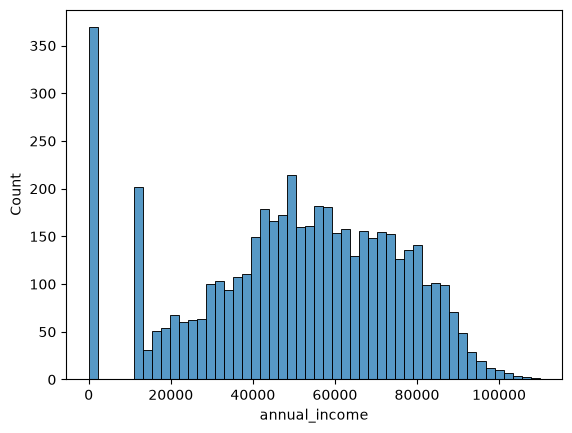

In [10]:
sns.histplot(df['annual_income'], bins=50)

In [11]:
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

In [12]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [18]:
correlation_columns = ['interaction_count', 'lead_score', 'annual_income', 'number_of_courses_viewed']

In [19]:
corr_matrix = df[correlation_columns].corr()

<Axes: >

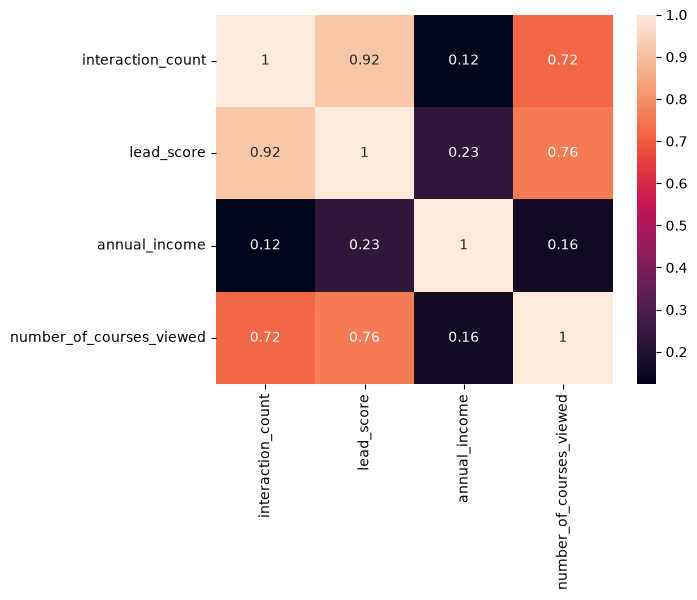

In [23]:
sns.heatmap(corr_matrix, annot=True)

In [26]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [27]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [29]:
df.nunique()

lead_source                    6
industry                       7
employment_status              5
location                       6
annual_income               4314
number_of_courses_viewed       7
interaction_count             14
lead_score                   100
converted                      2
dtype: int64

In [33]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [35]:
from sklearn.metrics import mutual_info_score

def mutual_info_churn_score(series):
    return round(mutual_info_score(series, y_train), 2)

In [36]:
mi = df_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

lead_source          0.03
employment_status    0.02
industry             0.00
location             0.00
dtype: float64

In [37]:
from sklearn.feature_extraction import DictVectorizer

In [38]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [40]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [41]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'annual_income': np.float64(-0.0),
 'employment_status=NA': np.float64(-0.001),
 'employment_status=employed': np.float64(0.007),
 'employment_status=self_employed': np.float64(-0.003),
 'employment_status=student': np.float64(-0.008),
 'employment_status=unemployed': np.float64(-0.006),
 'industry=NA': np.float64(-0.0),
 'industry=education': np.float64(-0.003),
 'industry=finance': np.float64(-0.001),
 'industry=healthcare': np.float64(-0.002),
 'industry=manufacturing': np.float64(-0.002),
 'industry=retail': np.float64(-0.002),
 'industry=technology': np.float64(-0.001),
 'interaction_count': np.float64(0.137),
 'lead_score': np.float64(0.011),
 'lead_source=NA': np.float64(0.0),
 'lead_source=events': np.float64(-0.009),
 'lead_source=organic_search': np.float64(0.007),
 'lead_source=paid_ads': np.float64(-0.014),
 'lead_source=referral': np.float64(0.009),
 'lead_source=social_media': np.float64(-0.004),
 'location=NA': np.float64(0.0),
 'location=africa': np.float64(-0.002),
 '

In [42]:
y_pred = model.predict_proba(X_val)[:, 1]

In [52]:
conversion_decision = (y_pred >= 0.5)
accuracy = (y_val == conversion_decision).mean()
accuracy

np.float64(0.645)

In [72]:
def feature_elimination(category):
    dv = DictVectorizer(sparse=False)
    
    columns = df.columns.tolist()
    columns.remove(category)
    columns.remove('converted')

    train_dict = df_train[columns].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    val_dict = df_val[columns].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    conversion_decision = (y_pred >= 0.5)
    new_accuracy = (y_val == conversion_decision).mean()

    print(f'Removed {category}. New accuracy: {new_accuracy}, Difference {accuracy - new_accuracy}')
    print()
    print()

In [68]:
exclude = ['lead_source', 'industry', 'employment_status']

for excluded_category in exclude:
    feature_elimination(excluded_category)

Removed lead_source. New accuracy: 0.642, Difference 0.0030000000000000027


Removed industry. New accuracy: 0.645, Difference 0.0


Removed employment_status. New accuracy: 0.645, Difference 0.0




In [71]:
def regularized_reg(C_VAL):
    dv = DictVectorizer(sparse=False)

    train_dict = df_train.to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    val_dict = df_val.to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=C_VAL, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]

    conversion_decision = (y_pred >= 0.5)
    new_accuracy = (y_val == conversion_decision).mean()

    print(f'Value {C}. New accuracy: {new_accuracy}, Difference {accuracy - new_accuracy}')
    print()
    print()

In [74]:
C_vals = [0.000001, 0.00001, 0.0001, 0.001]

for C in C_vals:
    regularized_reg(C)

Value 1e-06. New accuracy: 0.598, Difference 0.04700000000000004


Value 1e-05. New accuracy: 0.598, Difference 0.04700000000000004


Value 0.0001. New accuracy: 0.613, Difference 0.03200000000000003


Value 0.001. New accuracy: 0.645, Difference 0.0


